In [86]:
import pandas as pd
import numpy as np

In [87]:
df = pd.read_csv('../data/no-passes-data.csv', sep=',', keep_default_na=False)

In [88]:
df.isna().sum(axis=0).sort_values(ascending=False)

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 76, dtype: int64

In [89]:
df['SalePrice'] = np.log1p(df['SalePrice'])
df['SalePrice']

0       12.247699
1       12.109016
2       12.317171
3       11.849405
4       12.429220
          ...    
1453    12.072547
1454    12.254868
1455    12.493133
1456    11.864469
1457    11.901590
Name: SalePrice, Length: 1458, dtype: float64

In [90]:
df_no_binary = df.copy()

In [91]:
df_with_binary = df.copy()
df_with_binary['HasGarage'] = (df_with_binary['GarageCars'] > 0).astype(int)
df_with_binary['HasFireplace'] = (df_with_binary['Fireplaces'] > 0).astype(int)
df_with_binary['HasBsmt'] = (df_with_binary['TotalBsmtSF'] > 0).astype(int)
df_with_binary['HasPool'] = (df_with_binary['PoolArea'] > 0 ).astype(int)

In [92]:
from sklearn.preprocessing import OneHotEncoder

def oneHotEncoding(df):
  object_columns = df.select_dtypes('object').columns

  encoder = OneHotEncoder(sparse_output=False, drop='first')
  encoded = encoder.fit_transform(df[object_columns])
  encoded_cols = encoder.get_feature_names_out(object_columns)

  encoded_df = pd.DataFrame(data=encoded, columns=encoded_cols, index = df.index)

  df_encoded = pd.concat([df, encoded_df], axis=1)
  df_encoded = df_encoded.drop(columns=object_columns)
  
  return df_encoded



In [93]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

def getResiduals(df): 
  X = df.drop(columns=['SalePrice'])
  Y = df['SalePrice']

  X_train, X_test, Y_train, Y_test = train_test_split(X, Y, random_state=42, shuffle=True, test_size=0.2)

  LR_model = LinearRegression()

  LR_model.fit(X_train, Y_train)

  LR_predict = LR_model.predict(X_test)

  residuals = Y_test - LR_predict

  plt.scatter(LR_predict, residuals, alpha=0.5)
  plt.axhline(y=0, color='r')
  plt.xlabel('Predicted log_price')
  plt.ylabel('Residuals')

C:\Users\Татустик\AppData\Local\Temp\ipykernel_23236\996876940.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_columns = df.select_dtypes('object').columns


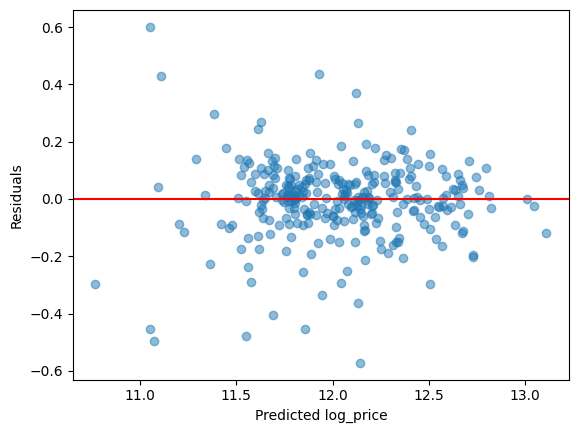

In [94]:
df_no_binary = oneHotEncoding(df_no_binary)
getResiduals(df_no_binary)

C:\Users\Татустик\AppData\Local\Temp\ipykernel_23236\996876940.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_columns = df.select_dtypes('object').columns


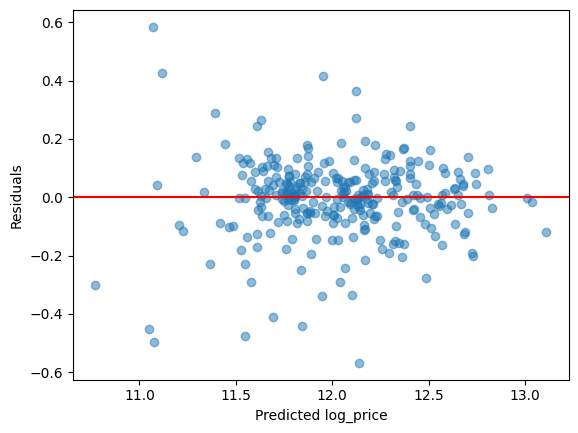

In [95]:
df_with_binary = oneHotEncoding(df_with_binary)
getResiduals(df_with_binary)